In [1]:
#@title Check if MuJoCo installation was successful

# from google.colab import files

import distutils.util
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import subprocess
if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.')

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags


Fri Mar 20 01:35:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:14:00.0 Off |                  Off |
| 30%   33C    P0             64W /  300W |   14239MiB /  49140MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#@title Import packages for plotting and creating graphics
import time
import itertools
import numpy as np
from typing import Callable, NamedTuple, Optional, Union, List

# Graphics and plotting.
print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [3]:
#@title Import MuJoCo, MJX, and Brax
from datetime import datetime
from etils import epath
import functools
from IPython.display import HTML
from typing import Any, Dict, Sequence, Tuple, Union
import os
from ml_collections import config_dict


import jax
from jax import numpy as jp
import numpy as np
from flax.training import orbax_utils
from flax import struct
from matplotlib import pyplot as plt
import mediapy as media
from orbax import checkpoint as ocp

import mujoco
from mujoco import mjx

from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks
from brax.io import html, mjcf, model


Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [28]:
# Path to the robot model
xml_path = "/home/luisamao/villa_spaces/sim_ws/robot_simple_collision.xml"

import os
import mujoco
import xml.etree.ElementTree as ET

# Load and process XML
print(f"Loading model from: {xml_path}")

tree = ET.parse(xml_path)
root = tree.getroot()
# base_dir = os.path.dirname(xml_path)
base_dir = "/home/luisamao/villa_spaces/sim_ws/src/mujoco_cobot/assets"

# 1. Resolve relative include paths
for include_elem in root.findall('include'):
    if 'file' in include_elem.attrib:
        rel_path = include_elem.attrib['file']
        abs_path = os.path.normpath(os.path.join(base_dir, rel_path))
        include_elem.attrib['file'] = abs_path

# 2. FIX: Ensure 'gym_floor_mat' exists
# Find or create the <asset> element
asset_elem = root.find('asset')
if asset_elem is None:
    asset_elem = ET.SubElement(root, 'asset')

# Resolve all mesh and texture paths to absolute paths
for tag in ['mesh', 'texture']:
    for elem in root.findall(f".//{tag}"):
        if 'file' in elem.attrib:
            rel_path = elem.attrib['file']
            # Only change if it's not already an absolute path
            if not os.path.isabs(rel_path):
                abs_path = os.path.normpath(os.path.join(base_dir, rel_path))
                elem.attrib['file'] = abs_path
                # Optional: print for debugging
                # print(f"Resolved {tag}: {rel_path} -> {abs_path}")

# Check if the material is already there; if not, add it
if root.find(".//material[@name='gym_floor_mat']") is None:
    print("Injecting missing 'gym_floor_mat' into assets...")
    # Add a default texture and material so the compiler doesn't crash
    ET.SubElement(asset_elem, 'texture', 
                  type='2d', name='gym_floor_tex', 
                  builtin='checker', rgb1='.2 .3 .4', rgb2='.1 .2 .3', 
                  width='512', height='512')
    ET.SubElement(asset_elem, 'material', 
                  name='gym_floor_mat', 
                  texture='gym_floor_tex', 
                  texrepeat='2 2', specular='0.3', shininess='0.5')

# 3. Convert to string
xml_string = ET.tostring(root, encoding='unicode')

# Compile MuJoCo model
mj_model = mujoco.MjModel.from_xml_string(xml_string)
# make data and renderer
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model)

# model.opt.iterations = 1  # Or 2-4 for more accuracy, but 1 is fastest
# model.opt.ls_iterations = 0 # Disable line search (uses while_loop)
# model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON
print(f"\nModel loaded successfully!")
print(f"  - DOFs: {mj_model.nv}")
print(f"  - Bodies: {mj_model.nbody}")
print(f"  - Joints: {mj_model.njnt}")
print(f"  - Actuators: {mj_model.nu}")

# Environment configuration
TIMESTEP = 0.002  # 2ms per step
BATCH_SIZE = 4 # 256  # Large batch size for parallel simulations
EPISODE_LENGTH = 20 # 200  # Steps per episode
NUM_EPISODES = 10 # 100  # Total training episodes
LEARNING_RATE = 1e-3

print(f"\nEnvironment Configuration:")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Episode Length: {EPISODE_LENGTH}")
print(f"  - Total Training Episodes: {NUM_EPISODES}")


Loading model from: /home/luisamao/villa_spaces/sim_ws/robot_simple_collision.xml
Injecting missing 'gym_floor_mat' into assets...

Model loaded successfully!
  - DOFs: 7
  - Bodies: 11
  - Joints: 7
  - Actuators: 7

Environment Configuration:
  - Batch Size: 4
  - Episode Length: 20
  - Total Training Episodes: 10


In [29]:

table_xml_path = "/home/luisamao/villa_spaces/sim_ws/table.xml" # The file we just created
worldbody = root.find('worldbody')

# 2. Inject the include tag into the worldbody
# This is like copy-pasting the table.xml content right here
ET.SubElement(worldbody, 'include', file=table_xml_path)

# --- 1. DEFINE THE DEFAULT CLASS ---
# Find or create the top-level <default> element
default_elem = root.find('default')
if default_elem is None:
    # Insert it at the beginning of the root so it's defined before use
    default_elem = ET.Element('default')
    root.insert(0, default_elem)

# Add the 'interactive' class definition inside <default>
# This is where 'armature' and 'damping' are safely stored
interactive_class = default_elem.find(".//default[@class='interactive']")
if interactive_class is None:
    interactive_class = ET.SubElement(default_elem, 'default', {'class': 'interactive'})
    # This regularizes the freejoint so CUSOLVER doesn't return NaNs
    ET.SubElement(interactive_class, 'joint', armature='0.01', damping='0.05')

# --- 2. INJECT THE BLOCK ---
block_size = [0.03, 0.03, 0.03]
block_pos = [0.8, 0, 0.72 + block_size[2] + 0.05] 

# Create block body referencing the class we just defined
block_body = ET.SubElement(worldbody, 'body', name='interactive_block', 
                           pos=' '.join(map(str, block_pos)),
                           childclass='interactive')

# The freejoint now "inherits" the armature from the 'interactive' class
ET.SubElement(block_body, 'freejoint', name='block_freejoint')

ET.SubElement(block_body, 'geom', 
              name='block_geom', 
              type='box', 
              size=' '.join(map(str, block_size)), 
              rgba='1 0 0 1',
              mass='0.1',
              # Increased first value for "grip"
              friction='1.5 0.01 0.0001', 
              # Enabled torsional friction
              condim='4',                  
              # Kept your stable MJX values
              solref='0.02 1.0',           
              solimp='0.9 0.95 0.001')

# 3. Resolve paths (as you did before)
# MuJoCo needs absolute paths for included files if they aren't in the same folder
for include_elem in root.findall('.//include'):
    if 'file' in include_elem.attrib:
        rel_path = include_elem.attrib['file']
        if not os.path.isabs(rel_path):
            abs_path = os.path.abspath(rel_path)
            include_elem.attrib['file'] = abs_path

# 4. Convert to string and compile
xml_string = ET.tostring(root, encoding='unicode')
mj_model = mujoco.MjModel.from_xml_string(xml_string)
mj_data = mujoco.MjData(mj_model)

print("Table successfully included from external XML!")

# 3. Convert to string
xml_string = ET.tostring(root, encoding='unicode')

# Compile MuJoCo model
mj_model = mujoco.MjModel.from_xml_string(xml_string)
# make data and renderer
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model)

# model.opt.iterations = 1  # Or 2-4 for more accuracy, but 1 is fastest
# model.opt.ls_iterations = 0 # Disable line search (uses while_loop)
# model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON
print(f"\nModel loaded successfully!")
print(f"  - DOFs: {mj_model.nv}")
print(f"  - Bodies: {mj_model.nbody}")
print(f"  - Joints: {mj_model.njnt}")
print(f"  - Actuators: {mj_model.nu}")

# Environment configuration
TIMESTEP = 0.002  # 2ms per step
BATCH_SIZE = 4 # 256  # Large batch size for parallel simulations
EPISODE_LENGTH = 20 # 200  # Steps per episode
NUM_EPISODES = 10 # 100  # Total training episodes
LEARNING_RATE = 1e-3

print(f"\nEnvironment Configuration:")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Episode Length: {EPISODE_LENGTH}")
print(f"  - Total Training Episodes: {NUM_EPISODES}")


Table successfully included from external XML!

Model loaded successfully!
  - DOFs: 13
  - Bodies: 13
  - Joints: 8
  - Actuators: 7

Environment Configuration:
  - Batch Size: 4
  - Episode Length: 20
  - Total Training Episodes: 10


In [11]:
# # 1. Higher accuracy (helps with blocks ghosting through things)
# # mj_model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON
# mj_model.opt.timestep = 0.00005 

mj_model.opt.solver = mujoco.mjtSolver.mjSOL_NEWTON
mj_model.opt.iterations = 30     # Increase from 6
mj_model.opt.ls_iterations = 10  # Important for Newton stability

# enable joint visualization option:
scene_option = mujoco.MjvOption()

# 2. Toggle the flags on this object
# These flags tell MuJoCo to draw the "debug" helpers
# geomgroup is a bitmask (boolean array). 
# Index 2 is visual, Index 3 is collision.
scene_option.geomgroup[2] = 1  # Show Visuals
scene_option.geomgroup[3] = 1  # Show Collisions

# Optional: Make visuals transparent so you can see the capsules inside
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False

scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = False
# scene_option.flags[mujoco.mjtVisFlag.mjVIS_FRAME] = True
scene_option.frame = mujoco.mjtFrame.mjFRAME_GEOM

duration = 3.8  # (seconds)
framerate = 60  # (Hz)

frames = []
mujoco.mj_resetData(mj_model, mj_data)
while mj_data.time < duration:
  mujoco.mj_step(mj_model, mj_data)
  if len(frames) < mj_data.time * framerate:
    renderer.update_scene(mj_data, scene_option=scene_option, camera="sideview")
    pixels = renderer.render()
    frames.append(pixels)

# Simulate and display video.
media.show_video(frames, fps=framerate, height=700)

In [12]:
import numpy as np

def print_collision_matrix_simple(model):
    n = model.ngeom
    # Get all geom names
    names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_GEOM, i) or f"g{i}" for i in range(n)]
    
    # Header
    header = " " * 38 + " ".join([f"{n[:3]:>3}" for n in names])
    print(header)
    print("-" * len(header))

    for i in range(n):
        row_str = f"{names[i]:>34} | "
        for j in range(n):
            type_i, aff_i = model.geom_contype[i], model.geom_conaffinity[i]
            type_j, aff_j = model.geom_contype[j], model.geom_conaffinity[j]
            
            # The MuJoCo collision rule: (TypeA & AffB) OR (TypeB & AffA)
            can_collide = (type_i & aff_j) > 0 or (type_j & aff_i) > 0
            
            symbol = "X" if can_collide else "."
            row_str += f"{symbol:>3} "
        print(row_str)

print_collision_matrix_simple(mj_model)

                                      flo  g1  g2  g3 sho hal hal hal hal for for sph sph sph sph g15 ee_ g17 tab tab tab tab tab blo
-------------------------------------------------------------------------------------------------------------------------------------
                             floor |   X   .   X   .   .   .   X   .   X   .   X   .   X   .   X   .   X   .   X   X   X   X   X   X 
                                g1 |   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
                                g2 |   X   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   X   .   X   X   X   X   X   X 
                                g3 |   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
              shoulder_link_visual |   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   . 
            half_arm_1_link_visual |   .   .   .   .   .   .  

In [30]:
import functools
import warnings
import jax
import jax.numpy as jp
from datetime import datetime
from brax import envs
from brax.envs.base import Env, PipelineEnv, State  # The fix for Brax 0.14.1
from brax.training.agents.ppo import train as ppo
import mujoco

from brax.io import mjcf

class CobotEnv(PipelineEnv):
    def __init__(self, target_pos=None, **kwargs):
        mj_model.opt.solver = mujoco.mjtSolver.mjSOL_CG
        mj_model.opt.iterations = 30     # Increase from 6
        mj_model.opt.ls_iterations = 10  # Important for Newton stability
        mj_model.opt.timestep = 0.0005


        sys = mjcf.load_model(mj_model)

        n_frames = 5
        super().__init__(sys, n_frames=n_frames, backend='mjx', **kwargs)

        self._ee_site_idx = mujoco.mj_name2id(
            sys.mj_model, mujoco.mjtObj.mjOBJ_SITE, 'pinch_site'
        )

        self._fixed_target = None
        if target_pos is not None:
            self._fixed_target = jp.array(target_pos)

    @property
    def action_size(self):
        return 11 # 4 (sin/cos pairs) + 3 (limited joints) = 11

    def reset(self, rng: jp.ndarray) -> State:
        # Create full arrays for the entire system (Robot 7 + Block 7)
        qpos = jp.zeros(self.sys.nq) # This will now be 14
        qvel = jp.zeros(self.sys.nv) # This will be 13 (7 robot + 6 block vel)
        
        # 1. Set Robot Home (Indices 0-6)
        robot_home = jp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
        qpos = qpos.at[:7].set(robot_home)
        # qpos = robot_home
        
        # 2. Set Block Initial Position (Indices 7-13)
        # Position [0.8, 0, 0.75] and Quaternion [1, 0, 0, 0] for no rotation
        block_home = jp.array([0.8, 0.0, 0.75, 1.0, 0.0, 0.0, 0.0])
        qpos = qpos.at[7:14].set(block_home)
        
        # Initialize the physics pipeline with the FULL state
        data = self.pipeline_init(qpos, qvel)
        
        obs = self._get_obs(data)
        reward, done = jp.zeros(2)
        metrics = {'dist': jp.zeros(()), 'floor_penalty': jp.zeros(())}

        # Target logic
        rng, target_key = jax.random.split(rng)
        low, high = jp.array([0.2, -0.5, 0.3]), jp.array([0.8, 0.5, 1.0])
        random_target_pos = jax.random.uniform(target_key, (3,), minval=low, maxval=high)
        target_pos = self._fixed_target if self._fixed_target is not None else random_target_pos
        
        new_mocap_pos = data.mocap_pos.at[0].set(target_pos)
        data = data.replace(mocap_pos=new_mocap_pos)

        info = {
            'prev_action': jp.zeros(self.action_size),
            'target_pos': target_pos
        }
                
        return State(data, obs, reward, done, metrics, info)
    
    # let ctrl be the 7-dim vector input in sim. let action be 11 dim output from policy
    def ctrl_to_action(self, ctrl_7: jp.ndarray) -> jp.ndarray:
        # Physical limits for the bounded joints (indices 1, 3, 5)
        low_lim = jp.array([-2.24, -2.57, -2.09])
        high_lim = jp.array([2.24, 2.57, 2.09])
        
        # 1. Infinite Joints: Map [-1, 1] to [-pi, pi] then to sin/cos
        # Indices 0, 2, 4, 6
        inf_angles = ctrl_7[jp.array([0, 2, 4, 6])]
        sins = jp.sin(inf_angles)
        coss = jp.cos(inf_angles)
        
        # 2. Limited Joints: Scale [-1, 1] to [low, high] radians
        # Indices 1, 3, 5
        lim_actions = ctrl_7[jp.array([1, 3, 5])]
        lim_norm = 2.0 * (lim_actions - low_lim) / (high_lim - low_lim) - 1.0
        
        # 3. Assemble 11-dim Control Vector
        ctrl_11 = jp.array([
            sins[0], coss[0], # J0 (Inf)
            lim_norm[0],    # J1 (Lim)
            sins[1], coss[1], # J2 (Inf)
            lim_norm[1],    # J3 (Lim)
            sins[2], coss[2], # J4 (Inf)
            lim_norm[2],    # J5 (Lim)
            sins[3], coss[3]  # J6 (Inf)
        ])
        return ctrl_11 

    def action_to_ctrl(self, action_11: jp.ndarray) -> jp.ndarray:
        """Converts 11-dim (sin/cos/lim) back to 7-dim radians."""
        # 1. Convert sin/cos pairs back to radians using atan2
        # atan2(sin, cos) returns the angle in [-pi, pi]
        rad_0 = jp.atan2(action_11[0], action_11[1])
        rad_2 = jp.atan2(action_11[3], action_11[4])
        rad_4 = jp.atan2(action_11[6], action_11[7])
        rad_6 = jp.atan2(action_11[9], action_11[10])
        
        # 2. Limited joints are already in radians (from the action_to_ctrl scaling)
        low_lim = jp.array([-2.24, -2.57, -2.09])
        high_lim = jp.array([2.24, 2.57, 2.09])
        rad_1 = action_11[2]
        rad_3 = action_11[5]
        rad_5 = action_11[8]
        # scale from [-1, 1] to limits
        rad_1 = low_lim[0] + (high_lim[0] - low_lim[0]) * (rad_1 + 1) / 2
        rad_3 = low_lim[1] + (high_lim[1] - low_lim[1]) * (rad_3 + 1) / 2
        rad_5 = low_lim[2] + (high_lim[2] - low_lim[2]) * (rad_5 + 1) / 2

        return jp.array([rad_0, rad_1, rad_2, rad_3, rad_4, rad_5, rad_6])
        
    def step(self, state: State, action: jp.ndarray) -> State:
        # 1. Action scaling
        scaled_action = self.action_to_ctrl(action)

        # 2. Get target from info and update mocap_pos BEFORE stepping
        # We use state.pipeline_state here because 'data' doesn't exist yet
        target_pos = state.info['target_pos']
        current_ps = state.pipeline_state.replace(
            mocap_pos=state.pipeline_state.mocap_pos.at[0].set(target_pos)
        )

        # 3. Step the physics (This creates the 'data' variable)
        data = self.pipeline_step(current_ps, scaled_action)
        
        # 4. Reward calculation (Now 'data' is defined and has the latest positions)
        hand_pos = data.site_xpos[self._ee_site_idx]
        dist = jp.linalg.norm(hand_pos - target_pos)
        
        reward_reach = -dist
        reward = reward_reach # - other costs...
        
        # 5. Logic for done and observations
        done = jp.zeros_like(dist)
        obs = self._get_obs(data)
        
        # Update metrics
        state.metrics.update(dist=dist, floor_penalty=0.0)
        
        return state.replace(pipeline_state=data, obs=obs, reward=reward, done=done)

    def _get_obs(self, data: mjx.Data) -> jp.ndarray:
        # Standard observation: joint positions and velocities
        # rel_pos = data.site_xpos[self._ee_site_idx] - self.target_pos
        target_pos = data.mocap_pos[0]  # Target position from mocap
        # The string "{}" tells JAX to print the corresponding argument
        # jax.debug.print("Shapes: qpos={}, qvel={}, target={}", 
        #         data.qpos.shape, data.qvel.shape, target_pos.shape)

        # Shapes: qpos=(Array(7, dtype=int32),), qvel=(Array(7, dtype=int32),), target=(Array(3, dtype=int32),)

        return jp.concatenate([data.qpos[:7], data.qvel[:7], target_pos]) # or give ee pos
        # return jp.concatenate([data.qpos, data.qvel, target_pos]) # or give ee pos

# Register the environment
envs.register_environment('cobot_reach', CobotEnv)


In [9]:
env_name = "cobot_reach"
env = envs.get_environment(env_name, target_pos = [.8, 0.0, .72+.05])

# define the jit reset/step functions
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

# initialize the state
state = jit_reset(jax.random.PRNGKey(0))
rollout = [state.pipeline_state]
og_pose = state.pipeline_state.q

# grab a trajectory
for i in range(500):
  ctrl = og_pose # [-0, 1.019, 0.144, 1.003, -0.221, 0.986, -0.886]
  ctrl = ctrl.at[0].set(min(i/300, 1.0)*3.14)
  ctrl = env.ctrl_to_action(ctrl)
  state = jit_step(state, ctrl)
  print("target pos:", state.pipeline_state.mocap_pos[0])
  print("ctrl:", ctrl)
  print("state:", state.pipeline_state.q)
  breakpoint()
  rollout.append(state.pipeline_state)

media.show_video(env.render(rollout, camera = "sideview"), fps=1.0 / env.dt)

/scratch/luisamao/conda/envs/cobot/lib/python3.10/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


target pos: [0.8  0.   0.77]
ctrl: [0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1.]
state: [ 0.  0.  0. -0. -0.  0. -0.]
target pos: [0.8  0.   0.77]
ctrl: [0.01 1.   0.   0.   1.   0.   0.   1.   0.   0.   1.  ]
state: [ 0.002  0.    -0.     0.    -0.    -0.    -0.   ]
target pos: [0.8  0.   0.77]
ctrl: [0.021 1.    0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
state: [ 0.005  0.    -0.     0.    -0.    -0.    -0.   ]
target pos: [0.8  0.   0.77]
ctrl: [0.031 1.    0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
state: [ 0.01  0.   -0.    0.   -0.    0.   -0.  ]
target pos: [0.8  0.   0.77]
ctrl: [0.042 0.999 0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
state: [ 0.016  0.    -0.     0.    -0.     0.    -0.   ]
target pos: [0.8  0.   0.77]
ctrl: [0.052 0.999 0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
state: [ 0.023  0.    -0.     0.    -0.     0.    -0.   ]
target pos: [0.8  0.   0.77]
ctrl: [0.063 0.998 0.    0.    1.    0.    0.    1.    0.    0.    1.   ]
sta

This browser does not support the video tag.


In [9]:
# List names of all cameras in the model
for i in range(mj_model.ncam):
    print(f"Camera ID: {i}, Name: {mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_CAMERA, i)}")

media.show_video(env.render(rollout), fps=1.0 / env.dt)

In [17]:
train_fn = functools.partial(
    ppo.train,
    num_timesteps=10_000_000, # 40_000_000, # Increased for better learning
    num_evals=10,
    reward_scaling=1/100,
    episode_length=1000,      # Increased so it has time to reach
    normalize_observations=True,
    entropy_cost = 1e-2,
    action_repeat=1,
    unroll_length=10,
    num_minibatches=24,
    num_updates_per_batch=8,
    discounting=0.99,
    learning_rate=3e-4,
    num_envs=2048,
    batch_size=512,
    seed=42
)

def progress_callback(num_steps, metrics):
    now = datetime.now().strftime('%H:%M:%S')
    
    # Use .get(key, default) to prevent KeyErrors
    reward = metrics.get('eval/episode_reward', 0.0)
    loss = metrics.get('training/total_loss', 0.0)
    sps = metrics.get('training/sps', 0.0)
    
    print(f"[{now}] Steps: {num_steps:>10} | Reward: {reward:>10.2f} | Loss: {loss:>10.4f} | SPS: {sps:>8.0f}")

print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting Training...")
make_inference_fn, params, metrics = train_fn(environment=envs.get_environment('cobot_reach'), progress_fn=progress_callback)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Training Complete!")

[01:43:45] Starting Training...


/scratch/luisamao/conda/envs/cobot/lib/python3.10/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(
/scratch/luisamao/conda/envs/cobot/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))
2026-03-20 01:44:47.719423: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-20 01:44:47.719459: W external/xla/xla/service/gpu/autotuning/dot_se

[01:46:42] Steps:          0 | Reward:    -757.59 | Loss:     0.0000 | SPS:        0
[01:54:06] Steps:    1228800 | Reward:    -557.39 | Loss:    -0.0448 | SPS:     3963
[01:59:05] Steps:    2457600 | Reward:    -315.97 | Loss:    -0.0759 | SPS:     5096
[02:04:13] Steps:    3686400 | Reward:    -161.59 | Loss:    -0.0674 | SPS:     4919
[02:09:13] Steps:    4915200 | Reward:    -153.52 | Loss:    -0.0529 | SPS:     5093
[02:14:20] Steps:    6144000 | Reward:    -143.99 | Loss:    -0.0462 | SPS:     4918
[02:19:19] Steps:    7372800 | Reward:    -134.70 | Loss:    -0.0392 | SPS:     5100
[02:24:18] Steps:    8601600 | Reward:    -122.88 | Loss:    -0.0348 | SPS:     5099
[02:29:26] Steps:    9830400 | Reward:    -119.00 | Loss:    -0.0351 | SPS:     4918
[02:34:25] Steps:   11059200 | Reward:    -115.61 | Loss:    -0.0272 | SPS:     5100
[02:34:27] Training Complete!


In [32]:
env_name = "cobot_reach"
# eval_env = envs.get_environment(env_name, target_pos = [.8, 0.0, .72+.05])
eval_env = envs.get_environment(env_name)

# model_path = 'mjx_brax_policy'
model_path = 'mjx_reach_point_table_collision_policy'
model.save_params(model_path, params)
# params = model.load_params(model_path)
# make_inference_fn, _, metrics = train_fn(environment=envs.get_environment('cobot_reach'), num_timesteps=0) # dummy train to get the make_inference_fn

# 3. Load parameters using Orbax
# ckpt_path = model_path
# checkpointer = ocp.PyTreeCheckpointer()
# # Restore parameters, often wrapped in a dictionary structure
# params = checkpointer.restore(ckpt_path)

# 4. Create the inference function
# The second parameter to ppo_networks.make_inference_fn is params
inference_fn = make_inference_fn(params)

In [ ]:
model_path = 'mjx_brax_policy'
# model.save_params(model_path, params)

params = model.load_params(model_path)
make_inference_fn, _, metrics = train_fn(environment=envs.get_environment('cobot_reach'), num_timesteps=0) # dummy train to get the make_inference_fn
inference_fn = make_inference_fn(params)

TypeError: tuple indices must be integers or slices, not str

In [19]:
# Check the input dimension of the first layer
# Brax PPO params are usually (normalizer_params, network_params)
network_params = params[1] 
# Access the first hidden layer's kernel (weight matrix)
first_kernel = network_params['params']['hidden_0']['kernel']
print(f"Your model was trained to accept an observation size of: {first_kernel.shape[0]}")

Your model was trained to accept an observation size of: 17


In [31]:
# examine the trained policy
env_name = "cobot_reach"
eval_env = envs.get_environment(env_name, target_pos = [.8, 0.0, .72+.05])
# eval_env = envs.get_environment(env_name)
inference_fn = jax.jit(make_inference_fn(params))
jit_inference_fn = jax.jit(inference_fn)

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)

# initialize the state
rng = jax.random.PRNGKey(0)
state = jit_reset(rng)
rollout = [state.pipeline_state]
print("obs shape", state.obs.shape)

# grab a trajectory
n_steps = 500
render_every = 2

for i in range(n_steps):
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state.pipeline_state)

  # print the reward
  print(f"Step {i+1}/{n_steps} | Reward: {state.reward:.3f} | Distance: {state.metrics['dist']:.3f}")

  if state.done:
    print("Done", len(rollout), n_steps)
    break

media.show_video(eval_env.render(rollout[::render_every], camera="sideview"), fps=1.0 / eval_env.dt / render_every)

/scratch/luisamao/conda/envs/cobot/lib/python3.10/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(
/scratch/luisamao/conda/envs/cobot/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


obs shape (17,)
Step 1/500 | Reward: -1.340 | Distance: 1.340
Step 2/500 | Reward: -1.339 | Distance: 1.339
Step 3/500 | Reward: -1.339 | Distance: 1.339
Step 4/500 | Reward: -1.341 | Distance: 1.341
Step 5/500 | Reward: -1.343 | Distance: 1.343
Step 6/500 | Reward: -1.345 | Distance: 1.345
Step 7/500 | Reward: -1.348 | Distance: 1.348
Step 8/500 | Reward: -1.352 | Distance: 1.352
Step 9/500 | Reward: -1.355 | Distance: 1.355
Step 10/500 | Reward: -1.358 | Distance: 1.358
Step 11/500 | Reward: -1.360 | Distance: 1.360
Step 12/500 | Reward: -1.362 | Distance: 1.362
Step 13/500 | Reward: -1.362 | Distance: 1.362
Step 14/500 | Reward: -1.362 | Distance: 1.362
Step 15/500 | Reward: -1.360 | Distance: 1.360
Step 16/500 | Reward: -1.358 | Distance: 1.358
Step 17/500 | Reward: -1.355 | Distance: 1.355
Step 18/500 | Reward: -1.350 | Distance: 1.350
Step 19/500 | Reward: -1.344 | Distance: 1.344
Step 20/500 | Reward: -1.337 | Distance: 1.337
Step 21/500 | Reward: -1.329 | Distance: 1.329
Step 2

This browser does not support the video tag.


In [21]:
media.show_video(eval_env.render(rollout[::render_every], camera="topdown"), fps=1.0 / eval_env.dt / render_every)

This browser does not support the video tag.


In [ ]:
# 1. Create the Scene Options object
scene_option = mujoco.MjvOption()

# 2. Toggle the flags on this object
# These flags tell MuJoCo to draw the "debug" helpers
# geomgroup is a bitmask (boolean array). 
# Index 2 is visual, Index 3 is collision.
scene_option.geomgroup[2] = 1  # Show Visuals
scene_option.geomgroup[3] = 1  # Show Collisions

# Optional: Make visuals transparent so you can see the capsules inside
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True

media.show_video(eval_env.render(rollout[::render_every], camera="topdown"), fps=1.0 / eval_env.dt / render_every)

This browser does not support the video tag.


In [16]:
import mujoco

def examine_collisions(model):
    print(f"{'ID':<5} | {'Geom Name':<25} | {'Type':<10} | {'Affinity':<10}")
    print("-" * 60)
    for i in range(model.ngeom):
        # Get the name of the geom
        name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_GEOM, i) or f"geom_{i}"
        
        contype = model.geom_contype[i]
        conaffinity = model.geom_conaffinity[i]
        
        print(f"{i:<5} | {name:<25} | {contype:<10} | {conaffinity:<10}")

examine_collisions(mj_model)

ID    | Geom Name                 | Type       | Affinity  
------------------------------------------------------------
0     | floor                     | 1          | 1         
1     | geom_1                    | 0          | 0         
2     | geom_2                    | 1          | 1         
3     | geom_3                    | 0          | 0         
4     | geom_4                    | 0          | 0         
5     | geom_5                    | 0          | 0         
6     | geom_6                    | 0          | 0         
7     | geom_7                    | 0          | 0         
8     | geom_8                    | 0          | 0         
9     | geom_9                    | 0          | 0         
10    | geom_10                   | 0          | 0         
11    | ee_collision              | 1          | 1         
12    | geom_12                   | 0          | 0         
13    | table_top                 | 1          | 1         
14    | table_leg_0               | 1  

In [15]:
# print the last control and the joint positions
print("Final Control:", ctrl)
print("Final Joint Positions:", state.pipeline_state.q)

Final Control: [-0.999  1.     0.382  1.     0.039  0.993 -0.777]
Final Joint Positions: [-1.001  1.02  -0.061  1.005  0.027  0.995 -0.737]


In [61]:
# media.show_video(env.render(rollout[::render_every]), fps=1.0 / env.dt / render_every)
print(len(rollout))

501


In [81]:
# Compare current joint positions to the model limits
qpos = state.pipeline_state.q
low, high = env.sys.mj_model.jnt_range.T

for i in range(env.sys.nq):
    print(f"Joint {i}: {qpos[i]:.3f} | Limits: [{low[i]:.3f}, {high[i]:.3f}]")

Joint 0: -0.997 | Limits: [-inf, inf]
Joint 1: 1.020 | Limits: [-2.240, 2.240]
Joint 2: -0.096 | Limits: [-inf, inf]
Joint 3: 1.003 | Limits: [-2.570, 2.570]
Joint 4: 0.166 | Limits: [-inf, inf]
Joint 5: 0.992 | Limits: [-2.090, 2.090]
Joint 6: 0.153 | Limits: [-inf, inf]


After strong control input:
Reward: -0.194 | Distance: 0.194


""

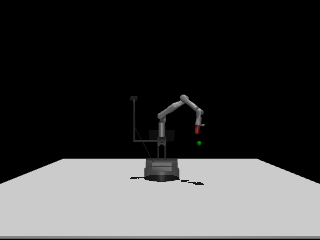

In [ ]:
# Instead of -0.1, try a stronger push toward the target
# the model is clipping the ctrl to -1,1 but this is interpreted by radians by the joint control...
ctrl = jp.array([-1.2,  1.,     0.382,  1.4,     0.039,  0.993, -0.777])
state = jit_step(state, ctrl)
print("After strong control input:")
print(f"Reward: {state.reward:.3f} | Distance: {state.metrics['dist']:.3f}")

single_frame_rollout = [state.pipeline_state]

# 3. Render and display
# We use media.show_image because it's a single frame
image = env.render(single_frame_rollout, camera="sideview")[0]
media.show_image(image)